In [3]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import h5py
from pyproj import Transformer
from tqdm import tqdm
import rasterio as rio

In [4]:
GRID = h5py.File('Data/SOhi_meta/SOhi_v1_GRID_v8.mat')
XC = np.asarray(GRID['XC'][0,:])
XC = ((XC + 180) %360) - 180

YC = np.asarray(GRID['YC'][:,0])

In [5]:
SOhi_ID_mask = np.load("Data/masks/SOhi_ID_mask.npy")

In [6]:
transformer = Transformer.from_crs("EPSG:3031","EPSG:4326")

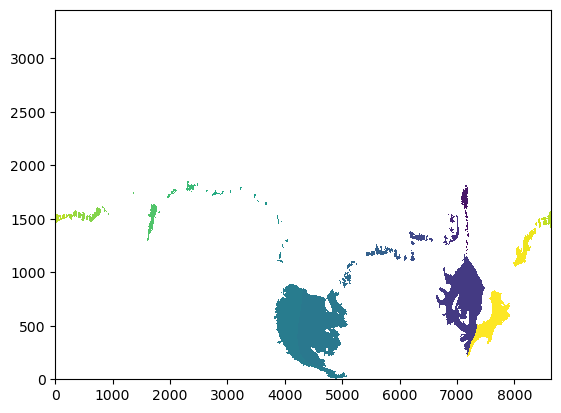

In [7]:
plt.pcolormesh(SOhi_ID_mask)

### Adusumilli

In [12]:
data = h5py.File('Data/melt_rates/adusumilli-2020/bb0448974g_3_1.h5')
X = np.asarray(data['x'][:,0])
Y = np.asarray(data['y'][:,0])
data = np.asarray(data['w_b'])

In [13]:
X.shape, X[0], X[-1], X[1] - X[0], X[-1] - X[-2]

((10941,),
 np.float64(-2736000.0),
 np.float64(2734000.0),
 np.float64(500.0),
 np.float64(500.0))

In [14]:
Y.shape, Y[0], Y[-1], Y[1] - Y[0], Y[-1] - Y[-2]

((10229,),
 np.float64(-2374000.0),
 np.float64(2740000.0),
 np.float64(500.0),
 np.float64(500.0))

In [15]:
data.shape

(10229, 10941)

In [16]:
Adu_ID_mask = np.zeros(data.shape)
Adu_ID_mask[:] = np.nan
for i in tqdm(range(data.shape[1])):
    for j in range(data.shape[0]): 
        if np.isnan(data[j, i]):
            continue
        else:
            lat, lon = transformer.transform(X[i], Y[j])
            iy = np.argmin(abs(YC-lat))
            ix = np.argmin(abs(XC-lon)) 

            if ~np.isnan(SOhi_ID_mask[iy, ix]):
                Adu_ID_mask[j, i] = SOhi_ID_mask[iy, ix]
            else:
                filled = False
                for count in range(20): 
                    test = set([i for i in SOhi_ID_mask[iy-count:iy+count+1, ix-count:ix+count+1].flatten() if ~np.isnan(i)])
                    if len(test) == 1:
                        Adu_ID_mask[j, i] = list(test)[0]
                        filled = True
                        break
                    elif len(test) > 1:
                        Adu_ID_mask[j, i] = 999
                        break 
                    else:
                        continue

                if not filled:
                    Adu_ID_mask[j, i] = 888

100%|█████████████████████████████████████| 10941/10941 [02:34<00:00, 70.59it/s]


In [18]:
Adu_ID_mask[Adu_ID_mask == 888] = np.nan
Adu_ID_mask[Adu_ID_mask == 999] = np.nan

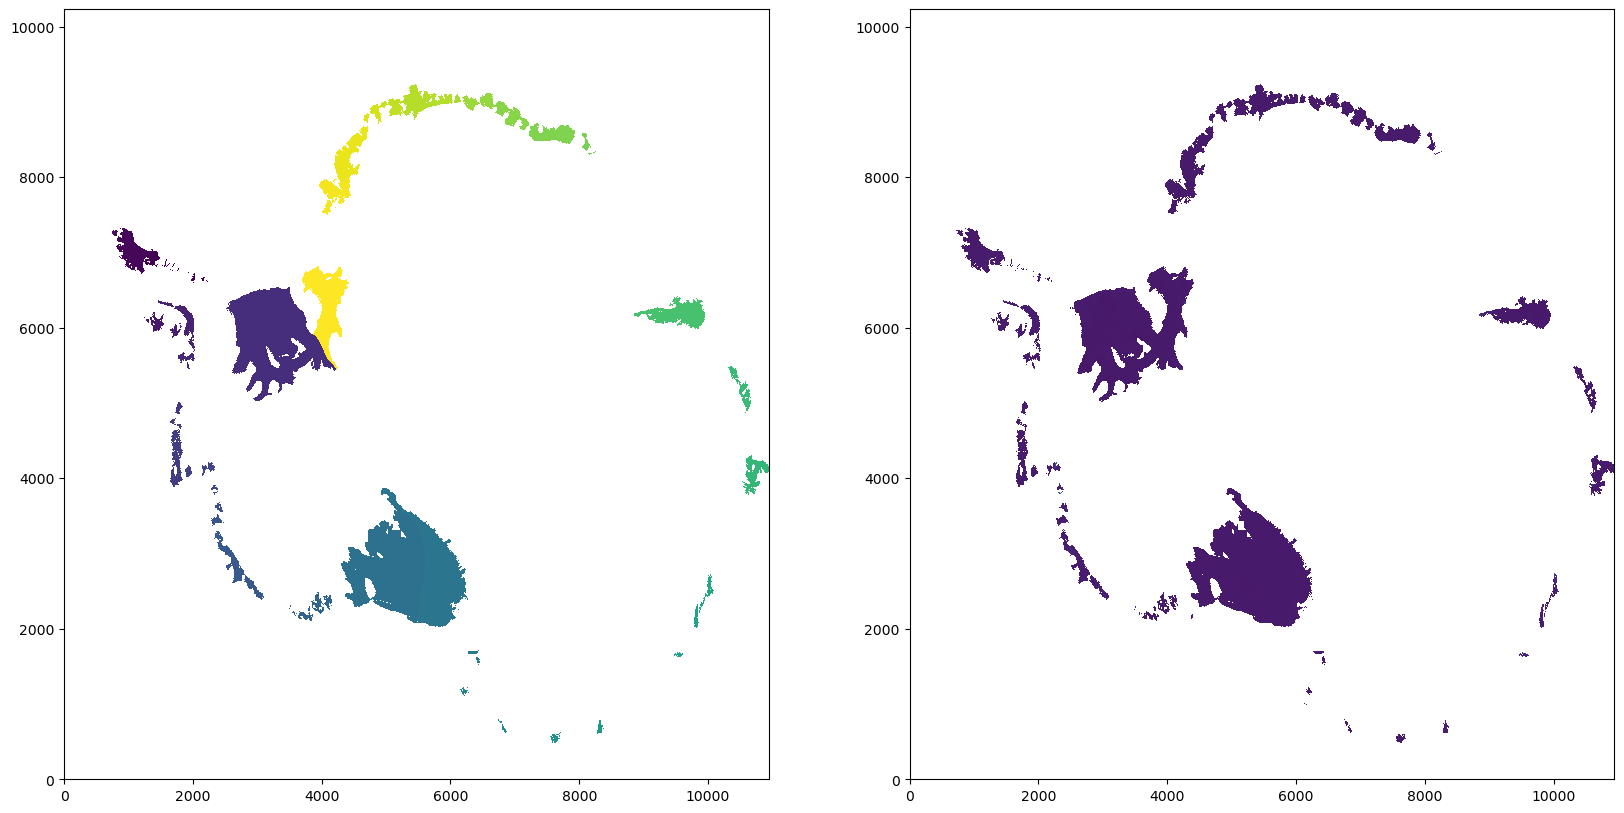

In [19]:
fig, ax = plt.subplots(figsize=(20,10), ncols=2)

ax[0].pcolormesh(Adu_ID_mask)
ax[1].pcolormesh(data)

In [25]:
transform = rio.transform.from_bounds(-2374000.0,
                                      -2736000.0,
                                      2740000.0,
                                      2734000.0,
                                      width=10229,
                                      height=10941)

profile = {
        'driver': 'GTiff',
        'dtype': np.float32,
        'nodata': 9999,
        'width': 10229,
        'height': 10941,
        'count': 1,
        'crs': "EPSG:3031", #CRS.from_proj4('+proj=lcc +lat_1=20 +lat_2=60 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m no_defs'),
        'transform': transform,
        'tiled': True,
        'compress': 'lzw'
        }

with rio.open("Data/masks/Adusumilli_ID_mask.tiff",'w',**profile) as dst:
        dst.write(Adu_ID_mask[::-1, ::],1)

In [27]:
transform = rio.transform.from_bounds(-2736000.0,
                                      -2374000.0,
                                      2734000.0,
                                      2740000.0,
                                      width=10941,
                                      height=10229)

profile = {
        'driver': 'GTiff',
        'dtype': np.float32,
        'nodata': 9999,
        'width': 10941,
        'height': 10229,
        'count': 1,
        'crs': "EPSG:3031", #CRS.from_proj4('+proj=lcc +lat_1=20 +lat_2=60 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m no_defs'),
        'transform': transform,
        'tiled': True,
        'compress': 'lzw'
        }

with rio.open("Data/masks/Adusumilli_ID_mask.tiff",'w',**profile) as dst:
        dst.write(Adu_ID_mask[::-1, ::],1)

In [21]:
np.save("Data/masks/Adusumilli_ID_mask.npy", Adu_ID_mask)

### Rignot

In [6]:
cube = nc.Dataset('Data/melt_rates/rignot-2013/Ant_MeltingRate.v2.nc')
X = np.asarray(cube['xaxis'])
Y = np.asarray(cube['yaxis'])
data = np.asarray(cube['melt_actual'])

In [7]:
data.shape

(5601, 5601)

In [8]:
X.shape, X[0], X[-1], X[1] - X[0], X[-1] - X[-2]

((5601,),
 np.float32(-2800000.0),
 np.float32(2800000.0),
 np.float32(1000.0),
 np.float32(1000.0))

In [9]:
Y.shape, Y[0], Y[-1], Y[1] - Y[0], Y[-1] - Y[-2]

((5601,),
 np.float32(2800000.0),
 np.float32(-2800000.0),
 np.float32(-1000.0),
 np.float32(-1000.0))

In [10]:
Rignot_ID_mask = np.zeros(data.shape)
Rignot_ID_mask[:] = np.nan
for i in tqdm(range(data.shape[1])):
    for j in range(data.shape[0]): 
        if np.isnan(data[j, i]):
            continue
        else:
            lat, lon = transformer.transform(X[i], Y[j])
            iy = np.argmin(abs(YC-lat))
            ix = np.argmin(abs(XC-lon)) 

            if ~np.isnan(SOhi_ID_mask[iy, ix]):
                Rignot_ID_mask[j, i] = SOhi_ID_mask[iy, ix]
            else:
                filled = False
                for count in range(10): 
                    test = set([i for i in SOhi_ID_mask[iy-count:iy+count+1, ix-count:ix+count+1].flatten() if ~np.isnan(i)])
                    if len(test) == 1:
                        Rignot_ID_mask[j, i] = list(test)[0]
                        filled = True
                        break
                    elif len(test) > 1:
                        Rignot_ID_mask[j, i] = 999
                        break 
                    else:
                        continue

                if not filled:
                    Rignot_ID_mask[j, i] = 888

100%|███████████████████████████████████████| 5601/5601 [00:59<00:00, 93.56it/s]


In [11]:
np.count_nonzero(Rignot_ID_mask == 999), np.count_nonzero(Rignot_ID_mask == 888)

(0, 14904)

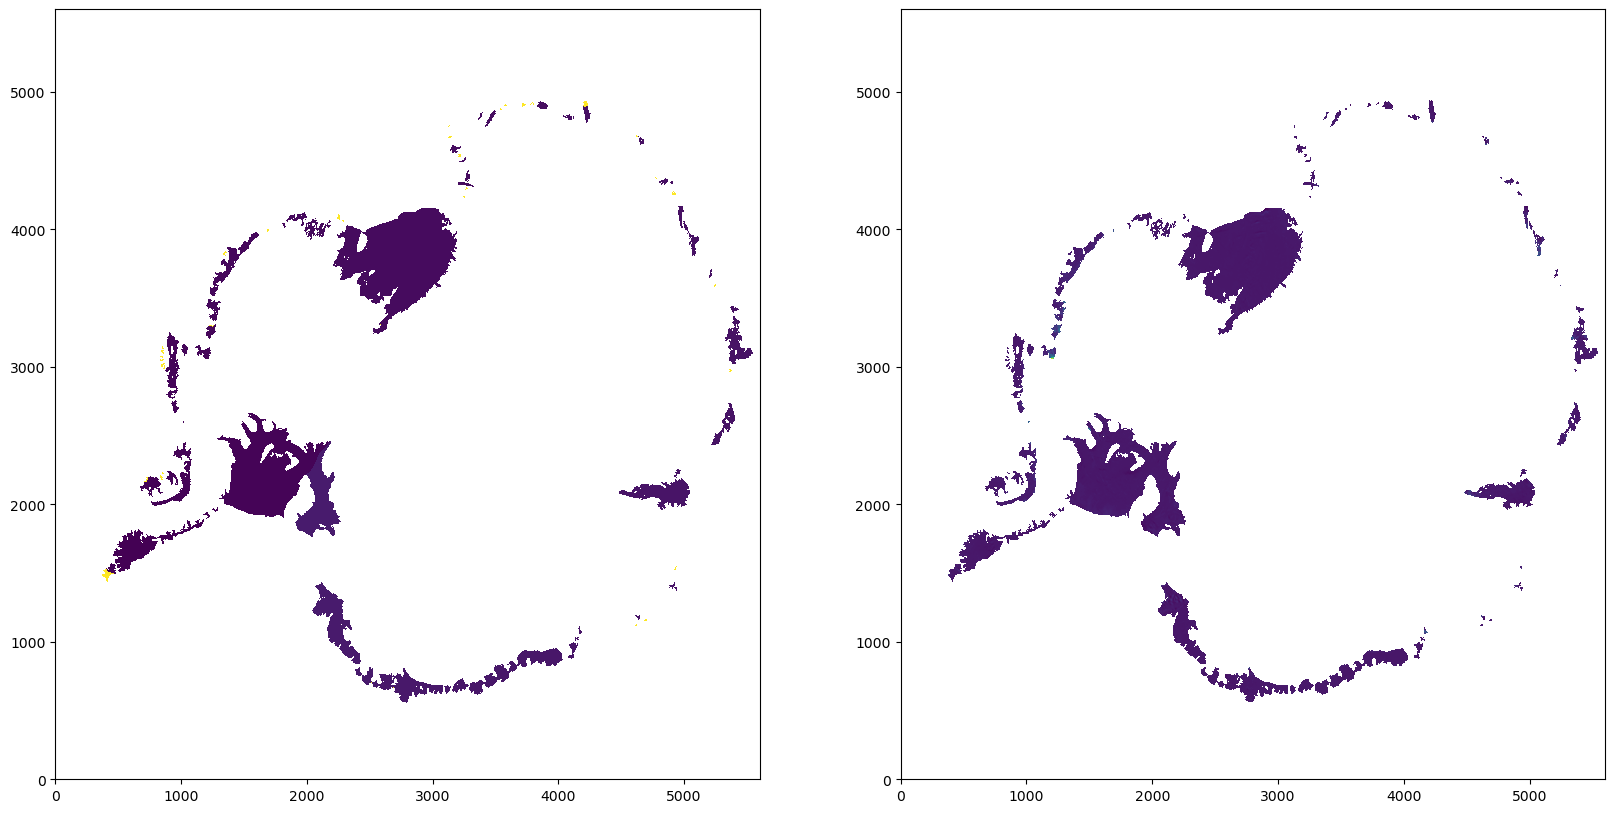

In [12]:
fig, ax = plt.subplots(figsize=(20,10), ncols=2)
ax[1].pcolormesh(data)
ax[0].pcolormesh(Rignot_ID_mask)


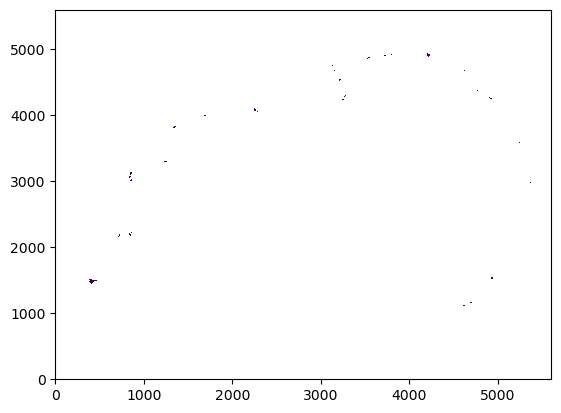

In [13]:
test = Rignot_ID_mask.copy()
test[test < 800] = np.nan
plt.pcolormesh(test)

In [14]:
Rignot_ID_mask[Rignot_ID_mask == 888] = np.nan
Rignot_ID_mask[Rignot_ID_mask == 999] = np.nan

In [15]:
Rignot_ID_mask.shape

(5601, 5601)

In [16]:
transform = rio.transform.from_bounds(-2800000.0,
                                      -2800000.0,
                                      2800000.0,
                                      2800000.0,
                                      width=5601, 
                                      height=5601)

profile = {
        'driver': 'GTiff',
        'dtype': np.float32,
        'nodata': 9999,
        'width': 5601,
        'height': 5601,
        'count': 1,
        'crs': "EPSG:3031", #CRS.from_proj4('+proj=lcc +lat_1=20 +lat_2=60 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m no_defs'),
        'transform': transform,
        'tiled': True,
        'compress': 'lzw'
        }

with rio.open("Data/masks/Rignot_ID_mask.tiff",'w',**profile) as dst:
        dst.write(Rignot_ID_mask[:, :],1)

In [17]:
np.save("Data/masks/Rignot_ID_mask.npy", Rignot_ID_mask)